# Per-basin driving attribute analysis for all 671 CAMELS basins

In my earlier work, I computed Transfer Entropy (TE) from four atmospheric forcings (PRCP, SRAD, Tair, VP) to streamflow Q for all 671 CAMELS basins, across lags 1 to 30 days. From those results, I already know for each basin which forcing is dominant and at what lag the TE peak occurs.

What I want to do now is go one step further. For every basin, I want to find which CAMELS attributes best explain why that basin is dominated by that forcing at that lag. One single attribute is not enough, because a basin's behavior is shaped by many factors together. So for each basin, I will list the top driving attributes in ranked order.

## My plan

1. Load my TE results (peak TE and peak lag for each forcing, per basin).
2. Load the CAMELS attributes for all 671 basins.
3. Merge the two tables on gauge_id.
4. Across all 671 basins, measure how strongly each attribute relates to each forcing's peak TE and peak lag. This gives me the population-level attribute relevance.
5. For each basin, measure how unusual it is on each attribute (z-score against the population).
6. Combine the population relevance with the basin's z-score to get a driver score per attribute.
7. Rank the attributes by driver score and keep the top 10 per basin.
8. Save the master table with one row per basin: gauge_id, dominant forcing, peak TE, peak lag, top 10 driving attributes with values and z-scores, and a short text summary.
9. Make CONUS maps and group plots to visualize the patterns.

## Goal

At the end, I want a single CSV table where each basin has a clear, ranked story of which attributes drive it. This way, for any of the 671 basins, I can answer the question "why is this basin dominated by this forcing at this lag?" using attribute-based evidence, not labels.


## Define project folder, output folders, and import libraries

In this step, I set the main project folder for this analysis and create three output subfolders: one for CSV summaries, one for PDF plots, and one for logs. I also import the libraries I need for data handling, statistics, and plotting.

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import pearsonr, spearmanr

In [2]:

# Main project folder for this new analysis
PROJECT_DIR = Path(r"C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Research -CAMELS\Analysis of all 671 basin")

# Output subfolders
OUT_DIR     = PROJECT_DIR / "outputs"
CSV_DIR     = OUT_DIR / "summary_csv"
PDF_DIR     = OUT_DIR / "pdf"
LOG_DIR     = OUT_DIR / "logs"

# Make sure the folders exist
for folder in [OUT_DIR, CSV_DIR, PDF_DIR, LOG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Quick check
print("Project folder:", PROJECT_DIR)
print("CSV output:    ", CSV_DIR)
print("PDF output:    ", PDF_DIR)
print("Log output:    ", LOG_DIR)

Project folder: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Research -CAMELS\Analysis of all 671 basin
CSV output:     C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Research -CAMELS\Analysis of all 671 basin\outputs\summary_csv
PDF output:     C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Research -CAMELS\Analysis of all 671 basin\outputs\pdf
Log output:     C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Research -CAMELS\Analysis of all 671 basin\outputs\logs


## Locate TE results and CAMELS attribute folders

In this step, I point to two folders from my earlier work. The first folder has my TE summary results for all 671 basins. The second folder has the merged CAMELS attribute table I built before. I list the CSV files inside each folder so I can pick the right ones to load.

In [3]:
# Folder with my earlier TE summary results
TE_DIR = Path(r"C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\summary_csv")

# Folder with my earlier CAMELS attribute summary
ATTR_DIR = Path(r"C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\TE basin to basin analysis with 60 attributes\outputs\summary_csv")

# List CSV files in the TE folder
print("Files in TE folder:")
for f in sorted(TE_DIR.glob("*.csv")):
    print(" ", f.name)

print()

# List CSV files in the attribute folder
print("Files in CAMELS attribute folder:")
for f in sorted(ATTR_DIR.glob("*.csv")):
    print(" ", f.name)

Files in TE folder:
  AllBasins_DataDateRanges.csv
  basin_to_basin_dominant_forcing.csv
  dominant_forcing_per_basin.csv
  dominant_te_per_basin.csv
  Probability_Distributions_Summary.csv
  Q_clean_continuity_check_all671.csv
  Q_cleaning_summary_from_raw_all671.csv
  Q_temporal_ranges_all671.csv
  Q_temporal_ranges_all671_cleanQ.csv
  Q_temporal_ranges_all671_rawfile.csv
  TE_AllBasins_tau1_30_PRCPspecial_bins5.csv
  TE_dominant_forcing_per_basin.csv
  TE_shuffle_all671_tau1_30_PRCPspecial_bins5.csv
  TimeSeries_DateRanges_All671.csv
  TimeSeries_DateRanges_AllYEAR_All671.csv

Files in CAMELS attribute folder:
  all_non_numeric_attributes_vs_forcing_peak_te_summary.csv
  budyko_class_summary_counts_671basins.csv
  budyko_classification_671basins.csv
  camels_attributes_combined_671basins.csv
  categorical_attributes_vs_peak_lag.csv
  categorical_attributes_vs_peak_TE.csv
  dominant_forcing_by_budyko_class_671basins.csv
  forcing_rank_summary_counts_671basins.csv
  forcing_ranking_pe

## Inspect the TE summary file and the CAMELS attribute file

In this step, I open the two main input files and check their shape and columns. The first file has forcing-wise peak TE and peak lag per basin. The second file has all CAMELS attributes per basin. I want to confirm both files cover the 671 basins and have the columns I expect.

In [5]:
# Both files live in the attribute folder from my earlier analysis
te_file   = ATTR_DIR / "forcing_wise_peak_te_lag_summary_671basins.csv"
attr_file = ATTR_DIR / "camels_attributes_combined_671basins.csv"

# Load TE summary
te_df = pd.read_csv(te_file)
print("TE summary file")
print("  Shape:", te_df.shape)
print("  Columns:", list(te_df.columns))
print(te_df.head())

print()

# Load CAMELS attributes
attr_df = pd.read_csv(attr_file)
print("CAMELS attribute file")
print("  Shape:", attr_df.shape)
print("  First 10 columns:", list(attr_df.columns)[:10])
print("  Total columns:", len(attr_df.columns))
print(attr_df.head())

TE summary file
  Shape: (671, 9)
  Columns: ['gauge_id', 'PRCP_peak_te', 'SRAD_peak_te', 'Tair_peak_te', 'VP_peak_te', 'PRCP_peak_lag', 'SRAD_peak_lag', 'Tair_peak_lag', 'VP_peak_lag']
   gauge_id  PRCP_peak_te  SRAD_peak_te  Tair_peak_te  VP_peak_te  \
0   1013500      0.002761      0.003063      0.004888    0.002685   
1   1022500      0.016681      0.004775      0.008300    0.006192   
2   1030500      0.013428      0.004072      0.007460    0.005949   
3   1031500      0.003859      0.001481      0.001351    0.001597   
4   1047000      0.002277      0.001389      0.001541    0.001330   

   PRCP_peak_lag  SRAD_peak_lag  Tair_peak_lag  VP_peak_lag  
0              1             13             14           22  
1              1              1              1            1  
2              1              5              2            2  
3              1              1              6            1  
4              1              3             17            1  

CAMELS attribute file
  Sh

## Standardize gauge_id and merge TE results with CAMELS attributes

In this step, I convert gauge_id in both tables to an 8-digit string. This is important because some CAMELS basin IDs start with a zero, and reading them as integers drops that zero. After fixing the format, I merge the TE summary table with the CAMELS attribute table on gauge_id. The merged table will have one row per basin with both TE results and all attributes side by side.

In [6]:
# Convert gauge_id to 8-digit string in both tables
te_df["gauge_id"]   = te_df["gauge_id"].astype(str).str.zfill(8)
attr_df["gauge_id"] = attr_df["gauge_id"].astype(str).str.zfill(8)

# Merge TE summary with CAMELS attributes on gauge_id
merged_df = te_df.merge(attr_df, on="gauge_id", how="left")

# Quick check
print("Merged table shape:", merged_df.shape)
print("Number of basins:", merged_df["gauge_id"].nunique())
print("Any basins missing attributes?:", merged_df.isna().any(axis=1).sum(), "rows have at least one NaN")
print()
print("First few rows of key columns:")
print(merged_df[["gauge_id", "PRCP_peak_te", "SRAD_peak_te", "Tair_peak_te", "VP_peak_te",
                 "PRCP_peak_lag", "SRAD_peak_lag", "Tair_peak_lag", "VP_peak_lag",
                 "p_mean", "frac_snow", "aridity"]].head())

Merged table shape: (671, 68)
Number of basins: 671
Any basins missing attributes?: 164 rows have at least one NaN

First few rows of key columns:
   gauge_id  PRCP_peak_te  SRAD_peak_te  Tair_peak_te  VP_peak_te  \
0  01013500      0.002761      0.003063      0.004888    0.002685   
1  01022500      0.016681      0.004775      0.008300    0.006192   
2  01030500      0.013428      0.004072      0.007460    0.005949   
3  01031500      0.003859      0.001481      0.001351    0.001597   
4  01047000      0.002277      0.001389      0.001541    0.001330   

   PRCP_peak_lag  SRAD_peak_lag  Tair_peak_lag  VP_peak_lag    p_mean  \
0              1             13             14           22  3.126679   
1              1              1              1            1  3.608126   
2              1              5              2            2  3.274405   
3              1              1              6            1  3.522957   
4              1              3             17            1  3.323146   


## Add dominant forcing, dominant peak TE, and dominant peak lag per basin

In this step, I look at the four forcing peak TE values for each basin and pick the largest one. The forcing with the largest peak TE is the dominant forcing for that basin. I also record the corresponding peak lag and the peak TE value itself. These three new columns will be used in every step that follows.

In [7]:
# Forcing names in the order we use them
forcings = ["PRCP", "SRAD", "Tair", "VP"]

# Peak TE columns and peak lag columns for the four forcings
peak_te_cols  = [f + "_peak_te"  for f in forcings]
peak_lag_cols = [f + "_peak_lag" for f in forcings]

# For each basin, find the forcing with the largest peak TE
merged_df["dominant_forcing"] = merged_df[peak_te_cols].idxmax(axis=1).str.replace("_peak_te", "", regex=False)

# Get the dominant peak TE value for each basin
merged_df["dominant_peak_te"] = merged_df[peak_te_cols].max(axis=1)

# Get the corresponding peak lag for the dominant forcing
merged_df["dominant_peak_lag"] = merged_df.apply(
    lambda row: row[row["dominant_forcing"] + "_peak_lag"], axis=1
)

# Quick check
print("Merged table shape now:", merged_df.shape)
print()
print("Counts of dominant forcing across 671 basins:")
print(merged_df["dominant_forcing"].value_counts())
print()
print("First few rows with the new columns:")
print(merged_df[["gauge_id", "dominant_forcing", "dominant_peak_te", "dominant_peak_lag"]].head(10))

Merged table shape now: (671, 71)

Counts of dominant forcing across 671 basins:
dominant_forcing
PRCP    388
SRAD    157
Tair     95
VP       31
Name: count, dtype: int64

First few rows with the new columns:
   gauge_id dominant_forcing  dominant_peak_te  dominant_peak_lag
0  01013500             Tair          0.004888                 14
1  01022500             PRCP          0.016681                  1
2  01030500             PRCP          0.013428                  1
3  01031500             PRCP          0.003859                  1
4  01047000             PRCP          0.002277                  1
5  01052500             Tair          0.006612                  1
6  01054200             Tair          0.003738                 12
7  01055000             SRAD          0.003516                  2
8  01057000             PRCP          0.002255                  1
9  01073000             PRCP          0.005689                  1


## Save the merged base table

In this step, I save the merged table that contains TE results, dominant forcing, dominant peak TE, dominant peak lag, and all CAMELS attributes per basin. This file is the base input for the rest of the analysis. Saving it as a CSV lets me reload it later without redoing the merge.

In [8]:
# Save the merged base table to the summary_csv folder
base_file = CSV_DIR / "merged_TE_attributes_with_dominant_671basins.csv"
merged_df.to_csv(base_file, index=False)

print("Saved base table:", base_file)
print("Shape:", merged_df.shape)

Saved base table: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Research -CAMELS\Analysis of all 671 basin\outputs\summary_csv\merged_TE_attributes_with_dominant_671basins.csv
Shape: (671, 71)


## Separate numeric attribute columns from identifiers and TE result columns

In this step, I build a clean list of numeric CAMELS attribute columns. I drop identifier columns (gauge_id, gauge_name, huc_02), TE result columns (peak TE and peak lag for each forcing), and the dominant-forcing columns I just created. This leaves only the basin attributes I will use to score drivers.

In [9]:
# Columns I do NOT want as attributes
exclude_cols = (
    ["gauge_id", "gauge_name", "huc_02"]
    + peak_te_cols
    + peak_lag_cols
    + ["dominant_forcing", "dominant_peak_te", "dominant_peak_lag"]
)

# All numeric columns in the merged table
numeric_cols_all = merged_df.select_dtypes(include=[np.number]).columns.tolist()

# Numeric attribute columns = numeric columns that are not in the exclude list
numeric_attr_cols = [c for c in numeric_cols_all if c not in exclude_cols]

# Non-numeric attribute columns (for reference, not used in scoring)
non_numeric_attr_cols = [c for c in merged_df.columns
                         if c not in exclude_cols
                         and c not in numeric_attr_cols]

# Quick check
print("Number of numeric attributes:", len(numeric_attr_cols))
print("Number of non-numeric attributes:", len(non_numeric_attr_cols))
print()
print("Numeric attribute columns:")
print(numeric_attr_cols)
print()
print("Non-numeric attribute columns:")
print(non_numeric_attr_cols)

Number of numeric attributes: 52
Number of non-numeric attributes: 5

Numeric attribute columns:
['p_mean', 'pet_mean', 'p_seasonality', 'frac_snow', 'aridity', 'high_prec_freq', 'high_prec_dur', 'low_prec_freq', 'low_prec_dur', 'glim_1st_class_frac', 'glim_2nd_class_frac', 'carbonate_rocks_frac', 'geol_porostiy', 'geol_permeability', 'q_mean', 'runoff_ratio', 'slope_fdc', 'baseflow_index', 'stream_elas', 'q5', 'q95', 'high_q_freq', 'high_q_dur', 'low_q_freq', 'low_q_dur', 'zero_q_freq', 'hfd_mean', 'soil_depth_pelletier', 'soil_depth_statsgo', 'soil_porosity', 'soil_conductivity', 'max_water_content', 'sand_frac', 'silt_frac', 'clay_frac', 'water_frac', 'organic_frac', 'other_frac', 'gauge_lat', 'gauge_lon', 'elev_mean', 'slope_mean', 'area_gages2', 'area_geospa_fabric', 'frac_forest', 'lai_max', 'lai_diff', 'gvf_max', 'gvf_diff', 'dom_land_cover_frac', 'root_depth_50', 'root_depth_99']

Non-numeric attribute columns:
['high_prec_timing', 'low_prec_timing', 'geol_1st_class', 'geol_2nd

## Cross-basin relevance: how strongly each attribute relates to each forcing's peak TE

In this step, I measure the population-level relationship between every numeric CAMELS attribute and each forcing's peak TE, across all 671 basins. I use Spearman rank correlation because most CAMELS attributes are not normally distributed and have outliers, and Spearman captures any monotonic relationship without assuming a straight line. The output is a table where each row is one attribute and the columns hold the Spearman correlation with PRCP peak TE, SRAD peak TE, Tair peak TE, and VP peak TE.

These correlations tell me which attributes are generally relevant to which forcing across the population. I will use them later as one part of the per-basin driver score.

In [10]:
# Build a table: rows = attributes, columns = Spearman correlation with each forcing's peak TE
relevance_rows = []

for attr in numeric_attr_cols:
    row = {"attribute": attr}
    for f in forcings:
        te_col = f + "_peak_te"
        # Drop NaN pairs only for this attribute and this forcing
        sub = merged_df[[attr, te_col]].dropna()
        if len(sub) >= 30:
            r, _ = spearmanr(sub[attr], sub[te_col])
        else:
            r = np.nan
        row[f + "_spearman"] = r
    relevance_rows.append(row)

attr_relevance_df = pd.DataFrame(relevance_rows)

# Also store the absolute correlation for ranking later
for f in forcings:
    attr_relevance_df[f + "_abs"] = attr_relevance_df[f + "_spearman"].abs()

# Save it
relevance_file = CSV_DIR / "attribute_relevance_to_each_forcing_peak_te_671basins.csv"
attr_relevance_df.to_csv(relevance_file, index=False)

print("Saved:", relevance_file)
print("Shape:", attr_relevance_df.shape)
print()

# Show top 10 attributes by absolute Spearman correlation, per forcing
for f in forcings:
    print(f"Top 10 attributes related to {f} peak TE (by absolute Spearman):")
    top = attr_relevance_df[["attribute", f + "_spearman", f + "_abs"]] \
            .sort_values(f + "_abs", ascending=False).head(10)
    print(top.to_string(index=False))
    print()

Saved: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Research -CAMELS\Analysis of all 671 basin\outputs\summary_csv\attribute_relevance_to_each_forcing_peak_te_671basins.csv
Shape: (52, 9)

Top 10 attributes related to PRCP peak TE (by absolute Spearman):
    attribute  PRCP_spearman  PRCP_abs
       p_mean       0.344487  0.344487
          q95       0.305122  0.305122
       q_mean       0.276749  0.276749
      aridity      -0.276032  0.276032
    gauge_lon      -0.271588  0.271588
p_seasonality      -0.244027  0.244027
     gvf_diff      -0.243038  0.243038
     hfd_mean      -0.237683  0.237683
 runoff_ratio       0.230815  0.230815
high_prec_dur       0.226635  0.226635

Top 10 attributes related to SRAD peak TE (by absolute Spearman):
     attribute  SRAD_spearman  SRAD_abs
 p_seasonality      -0.456859  0.456859
     gauge_lon      -0.432137  0.432137
           q95       0.431763  0.431763
  runoff_ratio       0.427830  0.427830
    slope_mean       0.3

In [41]:
for attr in numeric_attr_cols:
    row = {"attribute": attr}
    for f in forcings:
        te_col = f + "_peak_te"
        sub = merged_df[[attr, te_col]].dropna()

        # Print just the first combination to see what sub looks like
        print(f"attribute: {attr}   forcing: {f}")
        print(f"Number of rows: {len(sub)}")
        print(sub.head(10)) 
        break  
    break    

attribute: p_mean   forcing: PRCP
Number of rows: 671
     p_mean  PRCP_peak_te
0  3.126679      0.002761
1  3.608126      0.016681
2  3.274405      0.013428
3  3.522957      0.003859
4  3.323146      0.002277
5  3.730858      0.003615
6  4.067132      0.002115
7  3.494183      0.003136
8  3.570500      0.002255
9  3.503025      0.005689


## Compute z-scores for each basin on every numeric attribute

In this step, I measure how unusual each basin is on every numeric attribute. I do this by computing a z-score: how many standard deviations the basin sits away from the population mean. A z-score near zero means the basin is typical for that attribute. A large positive or negative z-score means the basin stands out. I treat the absolute z-score as "how unusual" the basin is, since both very high and very low values can be meaningful drivers.

If a basin has a missing value for an attribute, the z-score for that attribute will also be missing. I will handle that case in the driver-score step.

In [11]:
# For each numeric attribute, compute the z-score per basin
zscore_df = merged_df[["gauge_id"]].copy()

for attr in numeric_attr_cols:
    values = merged_df[attr]
    mean   = values.mean()
    std    = values.std()
    if std > 0:
        zscore_df[attr + "_z"] = (values - mean) / std
    else:
        zscore_df[attr + "_z"] = np.nan  # constant column, can't z-score

# Save z-score table
zscore_file = CSV_DIR / "basin_attribute_zscores_671basins.csv"
zscore_df.to_csv(zscore_file, index=False)

print("Saved:", zscore_file)
print("Z-score table shape:", zscore_df.shape)
print()

# Quick check: show z-scores for a few key attributes for the first 5 basins
check_cols = ["gauge_id", "p_mean_z", "frac_snow_z", "aridity_z", "elev_mean_z", "gauge_lat_z"]
print("Z-scores for first 5 basins on a few key attributes:")
print(zscore_df[check_cols].head())

Saved: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Research -CAMELS\Analysis of all 671 basin\outputs\summary_csv\basin_attribute_zscores_671basins.csv
Z-score table shape: (671, 53)

Z-scores for first 5 basins on a few key attributes:
   gauge_id  p_mean_z  frac_snow_z  aridity_z  elev_mean_z  gauge_lat_z
0  01013500 -0.092909     0.668199  -0.692108    -0.647728     1.534932
1  01022500  0.248436     0.332805  -0.762304    -0.848275     1.029984
2  01030500  0.011828     0.489034  -0.702584    -0.783237     1.201474
3  01031500  0.188051     0.561926  -0.761339    -0.650921     1.138877
4  01047000  0.046385     0.504282  -0.694755    -0.571302     1.080150


## Compute driver scores per basin per attribute

In this step, I combine two pieces of information for each basin and each attribute:

1. The basin's z-score on that attribute (how unusual the basin is on that attribute compared to the population).
2. The Spearman correlation between that attribute and the peak TE of the basin's dominant forcing (how much that attribute matters for that forcing across all 671 basins).

The driver score is the product of the two absolute values:

driver_score = |z_score| × |spearman_correlation|

A high driver score means the attribute is both unusual for this basin and relevant to the basin's dominant forcing. I also store the signed z-score and the signed correlation so I can later describe the direction of the effect.

The output is a long-format table where each row is one basin and one attribute, with the driver score, the z-score, the correlation, and the dominant forcing.

In [12]:
# Build a long-format table: one row per (basin, attribute)
driver_rows = []

# Lookup: dominant forcing per basin
basin_dom = merged_df[["gauge_id", "dominant_forcing", "dominant_peak_te", "dominant_peak_lag"]].copy()

# Lookup: Spearman correlation per attribute per forcing
# attr_relevance_df has columns: attribute, PRCP_spearman, SRAD_spearman, Tair_spearman, VP_spearman
relevance_lookup = attr_relevance_df.set_index("attribute")

for _, basin_row in basin_dom.iterrows():
    gid = basin_row["gauge_id"]
    dom = basin_row["dominant_forcing"]
    dom_te = basin_row["dominant_peak_te"]
    dom_lag = basin_row["dominant_peak_lag"]

    # Get this basin's z-scores
    z_row = zscore_df.loc[zscore_df["gauge_id"] == gid].iloc[0]

    for attr in numeric_attr_cols:
        z = z_row[attr + "_z"]
        r = relevance_lookup.loc[attr, dom + "_spearman"]

        if pd.notna(z) and pd.notna(r):
            score = abs(z) * abs(r)
        else:
            score = np.nan

        driver_rows.append({
            "gauge_id": gid,
            "dominant_forcing": dom,
            "dominant_peak_te": dom_te,
            "dominant_peak_lag": dom_lag,
            "attribute": attr,
            "z_score": z,
            "spearman_with_dom_forcing": r,
            "driver_score": score
        })

driver_long_df = pd.DataFrame(driver_rows)

# Save the long-format driver table
driver_long_file = CSV_DIR / "driver_scores_long_671basins.csv"
driver_long_df.to_csv(driver_long_file, index=False)

print("Saved:", driver_long_file)
print("Long table shape:", driver_long_df.shape)
print()

# Quick check: show top 10 driver attributes for the first basin
first_basin = driver_long_df["gauge_id"].iloc[0]
print(f"Top 10 driver attributes for basin {first_basin} (dominant forcing = "
      f"{driver_long_df.loc[driver_long_df['gauge_id']==first_basin,'dominant_forcing'].iloc[0]}):")
top_first = driver_long_df[driver_long_df["gauge_id"] == first_basin] \
              .sort_values("driver_score", ascending=False).head(10)
print(top_first[["attribute", "z_score", "spearman_with_dom_forcing", "driver_score"]].to_string(index=False))

Saved: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Research -CAMELS\Analysis of all 671 basin\outputs\summary_csv\driver_scores_long_671basins.csv
Long table shape: (34892, 8)

Top 10 driver attributes for basin 01013500 (dominant forcing = Tair):
     attribute   z_score  spearman_with_dom_forcing  driver_score
high_prec_freq -1.755910                  -0.491983      0.863877
     gauge_lat  1.534932                   0.505508      0.775921
 low_prec_freq -1.493571                  -0.504226      0.753097
      pet_mean -1.470002                  -0.331003      0.486575
     gauge_lon  1.678059                  -0.254598      0.427230
  runoff_ratio  0.670123                   0.555346      0.372150
     frac_snow  0.668199                   0.461141      0.308134
   frac_forest  0.715878                   0.345882      0.247610
    slope_mean -0.521082                   0.407422      0.212300
    water_frac  5.628304                   0.037402      0.210508


## Apply a minimum correlation filter and rebuild the driver-score table

When I looked at the first basin's top drivers, I noticed an issue with the simple driver-score formula. One attribute (water_frac) appeared in the top 10 only because the basin was extremely unusual on it (z-score over 5), even though that attribute has almost no population-level relationship with Tair peak TE (Spearman around 0.04). In other words, being unusual is not enough on its own. If the population correlation is essentially zero, the attribute is not a real driver, no matter how unusual the basin is.

To handle this, I add a minimum correlation filter. An attribute is eligible to be a driver for a basin only if its absolute Spearman correlation with the basin's dominant forcing is at least 0.10. This is a soft threshold that removes statistical noise but keeps any attribute with even a modest population-level signal. Anything below 0.10 is too weak to be defensible as a driver.

I keep the long table with all attributes for reference, but I add a column called "is_eligible" so I can filter out the noise when ranking the top drivers per basin.

In [13]:
# Minimum absolute Spearman correlation needed to count as a real driver
MIN_ABS_R = 0.10

# Add eligibility flag based on the absolute correlation
driver_long_df["is_eligible"] = driver_long_df["spearman_with_dom_forcing"].abs() >= MIN_ABS_R

# Save the updated long table (with eligibility)
driver_long_df.to_csv(driver_long_file, index=False)

# Quick check: how many attribute-basin pairs are eligible vs not
total = len(driver_long_df)
eligible = driver_long_df["is_eligible"].sum()
print(f"Total attribute-basin pairs: {total}")
print(f"Eligible pairs (|Spearman| >= {MIN_ABS_R}): {eligible}")
print(f"Excluded pairs (|Spearman| <  {MIN_ABS_R}): {total - eligible}")
print()

# Re-check top 10 drivers for basin 01013500 using only eligible attributes
first_basin = "01013500"
top_first = driver_long_df[
    (driver_long_df["gauge_id"] == first_basin) &
    (driver_long_df["is_eligible"])
].sort_values("driver_score", ascending=False).head(10)

print(f"Top 10 eligible driver attributes for basin {first_basin} "
      f"(dominant forcing = "
      f"{driver_long_df.loc[driver_long_df['gauge_id']==first_basin,'dominant_forcing'].iloc[0]}):")
print(top_first[["attribute", "z_score", "spearman_with_dom_forcing", "driver_score"]].to_string(index=False))

Total attribute-basin pairs: 34892
Eligible pairs (|Spearman| >= 0.1): 22209
Excluded pairs (|Spearman| <  0.1): 12683

Top 10 eligible driver attributes for basin 01013500 (dominant forcing = Tair):
     attribute   z_score  spearman_with_dom_forcing  driver_score
high_prec_freq -1.755910                  -0.491983      0.863877
     gauge_lat  1.534932                   0.505508      0.775921
 low_prec_freq -1.493571                  -0.504226      0.753097
      pet_mean -1.470002                  -0.331003      0.486575
     gauge_lon  1.678059                  -0.254598      0.427230
  runoff_ratio  0.670123                   0.555346      0.372150
     frac_snow  0.668199                   0.461141      0.308134
   frac_forest  0.715878                   0.345882      0.247610
    slope_mean -0.521082                   0.407422      0.212300
       aridity -0.692108                  -0.302883      0.209628


## Build the master per-basin table with top 10 driver attributes

In this step, I create the main output table of this analysis. Each row is one basin. For every basin, I take the top 10 eligible driver attributes (ranked by driver score) and place them in the row as ten attribute columns plus their z-scores, Spearman correlations, and driver scores. I also keep the gauge_id, the dominant forcing, the dominant peak TE, and the dominant peak lag.

This is the table I will use to answer "why is this basin dominated by this forcing at this lag?" for any of the 671 basins. The row for that basin contains the ranked attribute story.

In [14]:
# Number of top driver attributes to keep per basin
TOP_N = 10

# Build one row per basin
master_rows = []

for gid in merged_df["gauge_id"]:
    # Get the basin's metadata
    bm = merged_df.loc[merged_df["gauge_id"] == gid].iloc[0]
    dom = bm["dominant_forcing"]
    dom_te = bm["dominant_peak_te"]
    dom_lag = bm["dominant_peak_lag"]

    # Get this basin's eligible drivers, sorted by driver score
    sub = driver_long_df[
        (driver_long_df["gauge_id"] == gid) &
        (driver_long_df["is_eligible"])
    ].sort_values("driver_score", ascending=False).head(TOP_N)

    row = {
        "gauge_id": gid,
        "dominant_forcing": dom,
        "dominant_peak_te": dom_te,
        "dominant_peak_lag": dom_lag,
        "n_eligible_drivers": len(sub)
    }

    # Place top N attributes into wide columns
    for i in range(TOP_N):
        rank = i + 1
        if i < len(sub):
            r = sub.iloc[i]
            row[f"top{rank}_attribute"] = r["attribute"]
            row[f"top{rank}_zscore"]    = r["z_score"]
            row[f"top{rank}_spearman"]  = r["spearman_with_dom_forcing"]
            row[f"top{rank}_score"]     = r["driver_score"]
        else:
            row[f"top{rank}_attribute"] = np.nan
            row[f"top{rank}_zscore"]    = np.nan
            row[f"top{rank}_spearman"]  = np.nan
            row[f"top{rank}_score"]     = np.nan

    master_rows.append(row)

master_df = pd.DataFrame(master_rows)

# Save the master table
master_file = CSV_DIR / "per_basin_top10_drivers_671basins.csv"
master_df.to_csv(master_file, index=False)

print("Saved:", master_file)
print("Master table shape:", master_df.shape)
print()

# Show a few example rows: one PRCP-, one SRAD-, one Tair-, one VP-dominant basin
for f in forcings:
    example = master_df[master_df["dominant_forcing"] == f].iloc[0]
    print(f"Example {f}-dominant basin: {example['gauge_id']} "
          f"(peak TE = {example['dominant_peak_te']:.4f}, peak lag = {example['dominant_peak_lag']})")
    top_attrs = [example[f"top{i}_attribute"] for i in range(1, 6)]
    print(f"  Top 5 drivers: {top_attrs}")
    print()

Saved: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Research -CAMELS\Analysis of all 671 basin\outputs\summary_csv\per_basin_top10_drivers_671basins.csv
Master table shape: (671, 45)

Example PRCP-dominant basin: 01022500 (peak TE = 0.0167, peak lag = 1)
  Top 5 drivers: ['gauge_lon', 'slope_fdc', 'runoff_ratio', 'aridity', 'sand_frac']

Example SRAD-dominant basin: 01055000 (peak TE = 0.0035, peak lag = 2)
  Top 5 drivers: ['gauge_lon', 'runoff_ratio', 'gvf_diff', 'gauge_lat', 'q95']

Example Tair-dominant basin: 01013500 (peak TE = 0.0049, peak lag = 14)
  Top 5 drivers: ['high_prec_freq', 'gauge_lat', 'low_prec_freq', 'pet_mean', 'gauge_lon']

Example VP-dominant basin: 01451800 (peak TE = 0.0051, peak lag = 24)
  Top 5 drivers: ['high_prec_freq', 'runoff_ratio', 'aridity', 'slope_mean', 'pet_mean']



## Add gauge name to the master per-basin table

In this step, I read the CAMELS gauge information file, clean it, and merge the gauge name into the master per-basin table. After this, the master table will have gauge_id and gauge_name side by side, which makes the table easier to read.

In [17]:
# Read the gauge information file
# The header row mixes spaces and tabs, so we read with regex separator (any whitespace)
# and only use the first 3 columns: HUC_02, GAGE_ID, GAGE_NAME (rest of the line stays in GAGE_NAME)
gauge_info_file = Path(r"C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\basin_timeseries_v1p2_metForcing_obsFlow\basin_dataset_public_v1p2\basin_metadata\gauge_information.txt")

# Read raw lines and parse manually since the format is messy
records = []
with open(gauge_info_file, "r") as f:
    next(f)  # skip header line
    for line in f:
        parts = line.split("\t")
        # parts[0] = HUC, parts[1] = gauge_id, parts[2] = gauge_name (with extra spaces)
        if len(parts) >= 3:
            records.append({
                "gauge_id": parts[1].strip().zfill(8),
                "gauge_name": parts[2].strip()
            })

gauge_info_df = pd.DataFrame(records)

# Merge gauge name into the master table and place it right after gauge_id
master_df = master_df.merge(gauge_info_df, on="gauge_id", how="left")
cols = master_df.columns.tolist()
cols.insert(1, cols.pop(cols.index("gauge_name")))
master_df = master_df[cols]

# Save the updated master table
master_df.to_csv(master_file, index=False)

print("Updated master table saved with gauge name.")
print("Shape:", master_df.shape)
print("Basins missing gauge_name:", master_df["gauge_name"].isna().sum())
print()
print(master_df[["gauge_id", "gauge_name", "dominant_forcing", "dominant_peak_te", "dominant_peak_lag",
                 "top1_attribute", "top2_attribute", "top3_attribute"]].head(10))

Updated master table saved with gauge name.
Shape: (671, 46)
Basins missing gauge_name: 0

   gauge_id                                         gauge_name  \
0  01013500                   Fish River near Fort Kent, Maine   
1  01022500            Narraguagus River at Cherryfield, Maine   
2  01030500        Mattawamkeag River near Mattawamkeag, Maine   
3  01031500       Piscataquis River near Dover-Foxcroft, Maine   
4  01047000         Carrabassett River near North Anson, Maine   
5  01052500          Diamond River near Wentworth Location, NH   
6  01054200                        Wild River at Gilead, Maine   
7  01055000                    Swift River near Roxbury, Maine   
8  01057000  Little Androscoggin River near South Paris, Maine   
9  01073000                       OYSTER RIVER NEAR DURHAM, NH   

  dominant_forcing  dominant_peak_te  dominant_peak_lag  top1_attribute  \
0             Tair          0.004888                 14  high_prec_freq   
1             PRCP          0.01

## Sanity check: Top drivers for one example basin from each forcing group

In this step, I print the top 10 driver attributes for one example basin from each of the four forcing groups (PRCP, SRAD, Tair, VP). This is a quick sanity check. If the attribute stories look reasonable for each forcing type, the master table is trustworthy for all 671 basins.

In [18]:
for f in forcings:
    # Take the first basin in this group
    sub = master_df[master_df["dominant_forcing"] == f]
    if len(sub) == 0:
        continue
    row = sub.iloc[0]

    print(f"=== {f}-dominant example ===")
    print(f"  gauge_id:   {row['gauge_id']}")
    print(f"  gauge_name: {row['gauge_name']}")
    print(f"  peak TE:    {row['dominant_peak_te']:.4f}")
    print(f"  peak lag:   {row['dominant_peak_lag']}")
    print(f"  Top 10 drivers (attribute, z-score, Spearman with {f} peak TE, driver score):")
    for i in range(1, 11):
        attr = row[f"top{i}_attribute"]
        if pd.isna(attr):
            continue
        z = row[f"top{i}_zscore"]
        r = row[f"top{i}_spearman"]
        s = row[f"top{i}_score"]
        print(f"    {i:2d}. {attr:25s}  z={z:+.2f}  r={r:+.2f}  score={s:.3f}")
    print()

=== PRCP-dominant example ===
  gauge_id:   01022500
  gauge_name: Narraguagus River at Cherryfield, Maine
  peak TE:    0.0167
  peak lag:   1
  Top 10 drivers (attribute, z-score, Spearman with PRCP peak TE, driver score):
     1. gauge_lon                  z=+1.72  r=-0.27  score=0.467
     2. slope_fdc                  z=+1.06  r=+0.20  score=0.213
     3. runoff_ratio               z=+0.92  r=+0.23  score=0.213
     4. aridity                    z=-0.76  r=-0.28  score=0.210
     5. sand_frac                  z=+1.47  r=+0.12  score=0.172
     6. high_prec_dur              z=-0.76  r=+0.23  score=0.171
     7. elev_mean                  z=-0.85  r=-0.20  score=0.166
     8. pet_mean                   z=-1.20  r=-0.12  score=0.147
     9. glim_1st_class_frac        z=-0.96  r=-0.15  score=0.140
    10. root_depth_99              z=+1.35  r=+0.10  score=0.137

=== SRAD-dominant example ===
  gauge_id:   01055000
  gauge_name: Swift River near Roxbury, Maine
  peak TE:    0.0035
  pe

## Add a short text summary for each basin

In this step, I write a short auto-generated sentence for each basin that summarizes the dominant forcing, the peak lag, and the top three driver attributes with their z-score signs. This makes the master table easier to read without having to interpret z-scores and correlations by hand. The summary is mechanical and conservative. It only states what the numbers say, using cautious language like "is consistent with" rather than claiming causation.

In [19]:
def describe_basin(row):
    dom = row["dominant_forcing"]
    lag = int(row["dominant_peak_lag"])
    parts = []
    for i in range(1, 4):
        attr = row[f"top{i}_attribute"]
        z    = row[f"top{i}_zscore"]
        if pd.isna(attr):
            continue
        direction = "high" if z > 0 else "low"
        parts.append(f"{direction} {attr}")
    drivers_text = ", ".join(parts) if parts else "no eligible drivers"
    return (f"{dom}-dominant at lag {lag} day(s); "
            f"top drivers consistent with {drivers_text}.")

master_df["summary"] = master_df.apply(describe_basin, axis=1)

# Save the updated master table
master_df.to_csv(master_file, index=False)

print("Updated master table saved with summary text.")
print()
print("Examples:")
for f in forcings:
    sub = master_df[master_df["dominant_forcing"] == f].iloc[0]
    print(f"  [{sub['gauge_id']}] {sub['gauge_name']}")
    print(f"     {sub['summary']}")
    print()

Updated master table saved with summary text.

Examples:
  [01022500] Narraguagus River at Cherryfield, Maine
     PRCP-dominant at lag 1 day(s); top drivers consistent with high gauge_lon, high slope_fdc, high runoff_ratio.

  [01055000] Swift River near Roxbury, Maine
     SRAD-dominant at lag 2 day(s); top drivers consistent with high gauge_lon, high runoff_ratio, high gvf_diff.

  [01013500] Fish River near Fort Kent, Maine
     Tair-dominant at lag 14 day(s); top drivers consistent with low high_prec_freq, high gauge_lat, low low_prec_freq.

  [01451800] Jordan Creek near Schnecksville, PA
     VP-dominant at lag 24 day(s); top drivers consistent with high high_prec_freq, high runoff_ratio, low aridity.



## Confirm the master table covers all 671 basins

In this step, I confirm that the master per-basin driver table has one row for every basin in my dataset. I also print a few summary sentences picked from different parts of the country so I can see that the analysis ran across the full set, not just the first few rows.

In [20]:
# Total row count
print("Total basins in master table:", len(master_df))
print("Unique gauge_ids:", master_df["gauge_id"].nunique())
print()

# Counts by dominant forcing
print("Basins by dominant forcing:")
print(master_df["dominant_forcing"].value_counts())
print()

# Pick 8 random basins from across the table to show variety
sample = master_df.sample(n=8, random_state=42).sort_values("gauge_id")
print("Random sample of 8 basins from the master table:")
for _, row in sample.iterrows():
    print(f"  [{row['gauge_id']}] {row['gauge_name']}")
    print(f"     {row['summary']}")
    print()

Total basins in master table: 671
Unique gauge_ids: 671

Basins by dominant forcing:
dominant_forcing
PRCP    388
SRAD    157
Tair     95
VP       31
Name: count, dtype: int64

Random sample of 8 basins from the master table:
  [02314500] SUWANNEE RIVER AT US 441, AT FARGO, GA
     PRCP-dominant at lag 2 day(s); top drivers consistent with high organic_frac, high soil_conductivity, high soil_depth_pelletier.

  [03049000] Buffalo Creek near Freeport, PA
     VP-dominant at lag 19 day(s); top drivers consistent with low low_prec_freq, low high_prec_freq, high slope_fdc.

  [04185000] Tiffin River at Stryker OH
     PRCP-dominant at lag 1 day(s); top drivers consistent with high soil_depth_pelletier, high glim_2nd_class_frac, high gvf_diff.

  [05489000] Cedar Creek near Bussey, IA
     PRCP-dominant at lag 1 day(s); top drivers consistent with high p_seasonality, high hfd_mean, high gvf_diff.

  [06464500] KEYA PAHA R AT WEWELA SD
     PRCP-dominant at lag 1 day(s); top drivers consiste

## Build attribute explanation dictionary and add explanation columns to the master table

In this step, I write a short hydrologic explanation for each of the 52 numeric CAMELS attributes, separately for high and low values. These sentences are a reference glossary based on standard hydrology, not data-driven results. They are meant to make the master table easier to read by pairing each top driver with a one-line physical reason.

For every basin, I add ten new columns (top1_explanation through top10_explanation). The explanation chosen for each driver is based on the sign of the z-score, so a high attribute value gets the high explanation and a low attribute value gets the low explanation. I keep the language cautious. The wording uses "is associated with" or "may reflect" rather than claiming causation.

In [21]:
# Each entry: {"high": sentence for above-average value, "low": sentence for below-average value}
attribute_explanations = {
    "p_mean":              {"high": "high mean rainfall provides more water input, so rainfall information transfers more strongly to streamflow.",
                            "low":  "low mean rainfall limits the water input, so rainfall-driven information flow to streamflow is weaker."},
    "pet_mean":            {"high": "high potential evapotranspiration reflects an energy-rich climate where evaporation strongly modifies the water balance.",
                            "low":  "low potential evapotranspiration reflects a cool climate where evaporation losses are limited."},
    "p_seasonality":       {"high": "strong precipitation seasonality means rainfall is concentrated in part of the year, which sharpens seasonal streamflow response.",
                            "low":  "weak precipitation seasonality means rainfall is spread evenly through the year, which smooths the streamflow response."},
    "frac_snow":           {"high": "a large fraction of precipitation falls as snow, so streamflow is shaped by snow accumulation and melt rather than direct rainfall.",
                            "low":  "very little precipitation falls as snow, so streamflow is dominated by rainfall-driven processes."},
    "aridity":             {"high": "the basin is arid, so streamflow is water-limited and sensitive to evaporative demand.",
                            "low":  "the basin is humid, so streamflow is energy-limited and rainfall is rarely a limiting factor."},
    "high_prec_freq":      {"high": "frequent heavy rainfall events drive a strong, fast rainfall-runoff signal.",
                            "low":  "few heavy rainfall events mean streamflow is shaped more by slow processes such as snowmelt or baseflow."},
    "high_prec_dur":       {"high": "long heavy-rainfall events allow more soil saturation and stronger runoff response.",
                            "low":  "short heavy-rainfall events produce sharper but briefer runoff peaks."},
    "low_prec_freq":       {"high": "many dry days indicate a drier climate where streamflow depends on stored water.",
                            "low":  "few dry days indicate steady moisture supply, which supports continuous streamflow."},
    "low_prec_dur":        {"high": "long dry spells lead to drawdown of basin storage and slower streamflow response.",
                            "low":  "short dry spells limit basin drying and keep storage close to full."},
    "glim_1st_class_frac": {"high": "the basin is dominated by one main geological class, which gives a more uniform subsurface response.",
                            "low":  "the basin's main geological class covers only a small share, so the subsurface response is more mixed."},
    "glim_2nd_class_frac": {"high": "a large secondary geological class adds heterogeneity to the subsurface flow response.",
                            "low":  "a small secondary geological class means the subsurface is more uniform."},
    "carbonate_rocks_frac":{"high": "a high carbonate rock fraction is associated with karst-style flow paths and rapid subsurface drainage.",
                            "low":  "a low carbonate rock fraction reduces karst influence on streamflow."},
    "geol_porostiy":       {"high": "high geological porosity allows more subsurface storage and slower streamflow response.",
                            "low":  "low geological porosity reduces subsurface storage and produces a flashier response."},
    "geol_permeability":   {"high": "high geological permeability favors fast subsurface flow and stronger groundwater contribution.",
                            "low":  "low geological permeability slows subsurface flow and reduces groundwater contribution."},
    "q_mean":              {"high": "high mean streamflow gives a more dynamic Q signal, which generally raises information flow from forcings.",
                            "low":  "low mean streamflow limits the dynamic range of Q and weakens information flow from forcings."},
    "runoff_ratio":        {"high": "a high runoff ratio means most rainfall becomes streamflow, so the forcing-to-Q link is direct.",
                            "low":  "a low runoff ratio means most rainfall is lost to evaporation or storage, weakening the forcing-to-Q link."},
    "slope_fdc":           {"high": "a steep flow-duration curve indicates a flashy basin with quick rainfall response.",
                            "low":  "a flat flow-duration curve indicates a stable basin with slow streamflow variability."},
    "baseflow_index":      {"high": "a high baseflow index means streamflow is dominated by groundwater and slow drainage.",
                            "low":  "a low baseflow index means streamflow responds quickly to recent rainfall."},
    "stream_elas":         {"high": "high streamflow elasticity means small changes in rainfall produce large changes in streamflow.",
                            "low":  "low streamflow elasticity means streamflow is buffered against rainfall variability."},
    "q5":                  {"high": "high low-flow values reflect strong baseflow and steady year-round streamflow.",
                            "low":  "low low-flow values reflect basins that nearly dry out during dry periods."},
    "q95":                 {"high": "high peak-flow values reflect strong rainfall-runoff response and a wide streamflow range.",
                            "low":  "low peak-flow values reflect a damped streamflow response with limited peaks."},
    "high_q_freq":         {"high": "frequent high-flow events indicate a flashy, rainfall-driven streamflow regime.",
                            "low":  "infrequent high-flow events indicate a more stable streamflow regime."},
    "high_q_dur":          {"high": "long high-flow events suggest sustained wet conditions and slow recession.",
                            "low":  "short high-flow events suggest rapid recession and limited storage."},
    "low_q_freq":          {"high": "frequent low-flow events indicate a basin that often runs dry, possibly water-limited.",
                            "low":  "infrequent low-flow events indicate continuous streamflow throughout the year."},
    "low_q_dur":           {"high": "long low-flow events indicate prolonged dry periods and limited storage recharge.",
                            "low":  "short low-flow events indicate quick recovery from dry periods."},
    "zero_q_freq":         {"high": "frequent zero-flow days indicate an ephemeral or highly water-limited basin.",
                            "low":  "rare zero-flow days indicate a perennial streamflow regime."},
    "hfd_mean":            {"high": "a late half-flow date indicates streamflow is concentrated later in the water year, often due to snowmelt.",
                            "low":  "an early half-flow date indicates streamflow peaks early, typical of rainfall-dominated basins."},
    "soil_depth_pelletier":{"high": "deep soils provide more storage and slower release of water to streamflow.",
                            "low":  "shallow soils limit storage and produce a quicker streamflow response."},
    "soil_depth_statsgo":  {"high": "deep soils (STATSGO) increase basin storage and delay streamflow response.",
                            "low":  "shallow soils (STATSGO) reduce storage and lead to faster streamflow response."},
    "soil_porosity":       {"high": "high soil porosity increases water storage capacity and dampens streamflow response.",
                            "low":  "low soil porosity reduces water storage and produces a flashier response."},
    "soil_conductivity":   {"high": "high soil conductivity allows fast infiltration and subsurface flow.",
                            "low":  "low soil conductivity restricts infiltration, often increasing surface runoff."},
    "max_water_content":   {"high": "high maximum soil water content increases basin storage and delays streamflow.",
                            "low":  "low maximum soil water content limits storage and shortens streamflow response time."},
    "sand_frac":           {"high": "high sand fraction promotes fast infiltration and subsurface drainage.",
                            "low":  "low sand fraction reduces infiltration and may favor surface runoff."},
    "silt_frac":           {"high": "high silt fraction holds water and slows infiltration.",
                            "low":  "low silt fraction limits water retention in the soil column."},
    "clay_frac":           {"high": "high clay fraction reduces infiltration and increases surface runoff.",
                            "low":  "low clay fraction allows easier infiltration and reduces surface runoff."},
    "water_frac":          {"high": "a large fraction of water bodies in the basin buffers streamflow through lakes and wetlands.",
                            "low":  "few water bodies in the basin produce a more direct streamflow response."},
    "organic_frac":        {"high": "high organic soil fraction increases water retention and supports baseflow.",
                            "low":  "low organic soil fraction limits water retention."},
    "other_frac":          {"high": "a large 'other' land fraction reflects mixed or atypical surface cover.",
                            "low":  "a small 'other' land fraction reflects a more uniform basin."},
    "gauge_lat":           {"high": "northern latitude is associated with colder climates, more snow, and snowmelt-driven streamflow.",
                            "low":  "southern latitude is associated with warmer climates and rainfall-driven streamflow."},
    "gauge_lon":           {"high": "eastern longitude (less negative) is generally associated with humid conditions and stronger rainfall response.",
                            "low":  "western longitude (more negative) is generally associated with drier conditions and energy-limited streamflow."},
    "elev_mean":           {"high": "high elevation is associated with cooler temperatures, more snow, and delayed streamflow.",
                            "low":  "low elevation is associated with warmer temperatures and rainfall-driven streamflow."},
    "slope_mean":          {"high": "steep terrain promotes fast surface runoff and a quick streamflow response.",
                            "low":  "gentle terrain slows surface runoff and produces a smoother streamflow signal."},
    "area_gages2":         {"high": "a large drainage area integrates many sub-basin responses, producing a smoother streamflow signal.",
                            "low":  "a small drainage area produces a more direct response to local forcings."},
    "area_geospa_fabric":  {"high": "a large geospatial drainage area integrates many sub-basin responses.",
                            "low":  "a small geospatial drainage area gives a more direct streamflow response."},
    "frac_forest":         {"high": "high forest cover increases evapotranspiration and modifies the rainfall-runoff response.",
                            "low":  "low forest cover reduces evapotranspiration and may produce stronger surface runoff."},
    "lai_max":             {"high": "high maximum leaf area index reflects dense vegetation and strong seasonal ET.",
                            "low":  "low maximum leaf area index reflects sparse vegetation and limited ET."},
    "lai_diff":            {"high": "large leaf area seasonality reflects strong vegetation phenology, which drives a seasonal ET cycle.",
                            "low":  "small leaf area seasonality reflects evergreen or sparse vegetation with limited ET cycle."},
    "gvf_max":             {"high": "high maximum green vegetation fraction reflects dense canopy cover.",
                            "low":  "low maximum green vegetation fraction reflects sparse canopy cover."},
    "gvf_diff":            {"high": "strong seasonal vegetation cycle is associated with deciduous forests and a clear ET seasonality.",
                            "low":  "weak seasonal vegetation cycle is associated with evergreen or sparse vegetation."},
    "dom_land_cover_frac": {"high": "the basin is dominated by one land cover, giving a more uniform hydrologic response.",
                            "low":  "the basin has mixed land cover, producing a more heterogeneous response."},
    "root_depth_50":       {"high": "deep median rooting allows vegetation to access stored soil water during dry periods.",
                            "low":  "shallow median rooting limits vegetation water access to surface soils."},
    "root_depth_99":       {"high": "very deep maximum rooting allows vegetation to tap deep storage in droughts.",
                            "low":  "shallow maximum rooting limits vegetation reliance on deep storage."},
}

# Confirm we covered every numeric attribute
missing = [a for a in numeric_attr_cols if a not in attribute_explanations]
print("Attributes without explanation:", missing)

# Add explanation columns to the master table
def pick_explanation(attr, z):
    if pd.isna(attr) or attr not in attribute_explanations:
        return ""
    return attribute_explanations[attr]["high"] if z > 0 else attribute_explanations[attr]["low"]

for i in range(1, 11):
    master_df[f"top{i}_explanation"] = master_df.apply(
        lambda row: pick_explanation(row[f"top{i}_attribute"], row[f"top{i}_zscore"]),
        axis=1
    )

# Save the updated master table
master_df.to_csv(master_file, index=False)

print("Updated master table saved with explanation columns.")
print("Shape:", master_df.shape)
print()

# Quick check: show full top-10 story for the first Tair-dominant basin
example = master_df[master_df["dominant_forcing"] == "Tair"].iloc[0]
print(f"Example: [{example['gauge_id']}] {example['gauge_name']}")
print(f"  {example['summary']}")
print()
for i in range(1, 11):
    a = example[f"top{i}_attribute"]
    if pd.isna(a):
        continue
    z = example[f"top{i}_zscore"]
    e = example[f"top{i}_explanation"]
    print(f"  {i:2d}. {a} (z={z:+.2f}) — {e}")

Attributes without explanation: []
Updated master table saved with explanation columns.
Shape: (671, 57)

Example: [01013500] Fish River near Fort Kent, Maine
  Tair-dominant at lag 14 day(s); top drivers consistent with low high_prec_freq, high gauge_lat, low low_prec_freq.

   1. high_prec_freq (z=-1.76) — few heavy rainfall events mean streamflow is shaped more by slow processes such as snowmelt or baseflow.
   2. gauge_lat (z=+1.53) — northern latitude is associated with colder climates, more snow, and snowmelt-driven streamflow.
   3. low_prec_freq (z=-1.49) — few dry days indicate steady moisture supply, which supports continuous streamflow.
   4. pet_mean (z=-1.47) — low potential evapotranspiration reflects a cool climate where evaporation losses are limited.
   5. gauge_lon (z=+1.68) — eastern longitude (less negative) is generally associated with humid conditions and stronger rainfall response.
   6. runoff_ratio (z=+0.67) — a high runoff ratio means most rainfall becomes str

## Save the per-basin driver report as a PDF

In this step, I save the full per-basin driver story as a multi-page PDF. Each page covers one basin and shows the gauge ID, gauge name, dominant forcing, peak TE, peak lag, the short summary sentence, and the top ten driver attributes with their z-scores, Spearman correlations with the dominant forcing, driver scores, and a one-line hydrologic explanation. The PDF is meant to be flipped through during meetings to find any basin's story quickly.

In [22]:
# PDF output path
pdf_file = PDF_DIR / "per_basin_top10_drivers_671basins.pdf"

# Sort the table so basins appear in gauge_id order
report_df = master_df.sort_values("gauge_id").reset_index(drop=True)

with PdfPages(pdf_file) as pdf:
    for _, row in report_df.iterrows():
        fig, ax = plt.subplots(figsize=(8.5, 11))
        ax.axis("off")

        # Header block
        header_lines = [
            f"Basin {row['gauge_id']}: {row['gauge_name']}",
            f"Dominant forcing: {row['dominant_forcing']}    "
            f"Peak TE: {row['dominant_peak_te']:.4f}    "
            f"Peak lag: {int(row['dominant_peak_lag'])} day(s)",
            f"Summary: {row['summary']}"
        ]

        y = 0.96
        ax.text(0.02, y, header_lines[0], fontsize=14, fontweight="bold", transform=ax.transAxes)
        y -= 0.04
        ax.text(0.02, y, header_lines[1], fontsize=11, transform=ax.transAxes)
        y -= 0.035
        ax.text(0.02, y, header_lines[2], fontsize=10, style="italic",
                transform=ax.transAxes, wrap=True)
        y -= 0.05

        # Section title
        ax.text(0.02, y, "Top 10 driver attributes", fontsize=12, fontweight="bold",
                transform=ax.transAxes)
        y -= 0.035

        # Drivers list
        for i in range(1, 11):
            attr = row[f"top{i}_attribute"]
            if pd.isna(attr):
                continue
            z = row[f"top{i}_zscore"]
            r = row[f"top{i}_spearman"]
            s = row[f"top{i}_score"]
            e = row[f"top{i}_explanation"]

            # Attribute line
            line1 = f"{i:2d}. {attr}    z = {z:+.2f}    r = {r:+.2f}    score = {s:.3f}"
            ax.text(0.02, y, line1, fontsize=10, fontweight="bold",
                    family="monospace", transform=ax.transAxes)
            y -= 0.025

            # Wrap explanation across multiple lines if long
            words = e.split()
            line = ""
            for w in words:
                if len(line) + len(w) + 1 > 105:
                    ax.text(0.05, y, line, fontsize=9, transform=ax.transAxes)
                    y -= 0.022
                    line = w
                else:
                    line = (line + " " + w).strip()
            if line:
                ax.text(0.05, y, line, fontsize=9, transform=ax.transAxes)
                y -= 0.03

        # Footer note
        ax.text(0.02, 0.02,
                "Note: TE shows lagged information flow, not direct causation. "
                "Driver scores combine population-level relevance with how unusual the basin is on each attribute.",
                fontsize=8, style="italic", color="gray", transform=ax.transAxes, wrap=True)

        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print("Saved PDF:", pdf_file)
print("Pages:", len(report_df))

Saved PDF: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Research -CAMELS\Analysis of all 671 basin\outputs\pdf\per_basin_top10_drivers_671basins.pdf
Pages: 671


## Add a dominance margin column

In this step, I add two columns to the master table that describe how clearly the dominant forcing is dominant for each basin. The first is the absolute margin, which is the dominant forcing peak TE minus the second-largest forcing peak TE. The second is the relative margin, which is the absolute margin divided by the dominant peak TE, expressed as a percent. A small margin means the dominance label is technically correct but weakly separated. A large margin means the dominance is strong and clearly separated. This column helps me flag basins where the dominance label should be interpreted with caution.

In [23]:
# For each basin, compute the dominance margin
def dominance_margin(row):
    te_values = sorted([row[c] for c in peak_te_cols], reverse=True)
    abs_margin = te_values[0] - te_values[1]
    rel_margin = abs_margin / te_values[0] * 100 if te_values[0] > 0 else np.nan
    return pd.Series({"dominance_abs_margin": abs_margin,
                      "dominance_rel_margin_pct": rel_margin})

margin_df = merged_df.apply(dominance_margin, axis=1)
margin_df["gauge_id"] = merged_df["gauge_id"].values

# Merge into master_df
master_df = master_df.merge(margin_df, on="gauge_id", how="left")

# Place the two new columns right after dominant_peak_lag
cols = master_df.columns.tolist()
for new_col in ["dominance_abs_margin", "dominance_rel_margin_pct"]:
    cols.remove(new_col)
insert_at = cols.index("dominant_peak_lag") + 1
cols = cols[:insert_at] + ["dominance_abs_margin", "dominance_rel_margin_pct"] + cols[insert_at:]
master_df = master_df[cols]

# Save the updated master table
master_df.to_csv(master_file, index=False)

# Quick check: distribution of relative margin
print("Relative dominance margin (%) distribution across 671 basins:")
print(master_df["dominance_rel_margin_pct"].describe().round(2))
print()

# Show how many basins fall into different margin categories
bins = [0, 5, 10, 25, 50, 100]
labels = ["<5% (very weak)", "5-10% (weak)", "10-25% (moderate)", "25-50% (strong)", ">50% (very strong)"]
master_df["dominance_strength"] = pd.cut(master_df["dominance_rel_margin_pct"],
                                          bins=bins, labels=labels, include_lowest=True)
print("Basins by dominance strength category:")
print(master_df["dominance_strength"].value_counts().sort_index())
print()

# Save updated table again with the strength column
master_df.to_csv(master_file, index=False)

Relative dominance margin (%) distribution across 671 basins:
count    671.00
mean      28.26
std       20.03
min        0.18
25%       10.51
50%       24.71
75%       44.42
max       76.65
Name: dominance_rel_margin_pct, dtype: float64

Basins by dominance strength category:
dominance_strength
<5% (very weak)        65
5-10% (weak)           95
10-25% (moderate)     177
25-50% (strong)       208
>50% (very strong)    126
Name: count, dtype: int64



## Group-level summary: which attributes drive each forcing group most often

In this step, I aggregate the per-basin driver results across all basins within each dominant forcing group. For each forcing (PRCP, SRAD, Tair, VP), I count how often each attribute appears in the top 10 drivers across all basins in that group, and I also compute the average driver score for each attribute within the group. The result is a ranked list per forcing that tells me which attributes are the most common and strongest drivers for basins where that forcing dominates. This is the group-level story I can use to summarize patterns across all 671 basins.

In [24]:
# Build a long table of (basin, dominant forcing, top attribute, driver score) using only top-10 entries
group_rows = []
for _, row in master_df.iterrows():
    dom = row["dominant_forcing"]
    for i in range(1, 11):
        attr = row[f"top{i}_attribute"]
        if pd.isna(attr):
            continue
        score = row[f"top{i}_score"]
        group_rows.append({
            "dominant_forcing": dom,
            "attribute": attr,
            "driver_score": score,
            "rank": i
        })

group_long = pd.DataFrame(group_rows)

# For each forcing, count appearances and average driver score
group_summary = (group_long
                 .groupby(["dominant_forcing", "attribute"])
                 .agg(n_basins_in_top10=("attribute", "size"),
                      mean_driver_score=("driver_score", "mean"),
                      mean_rank=("rank", "mean"))
                 .reset_index())

# For each forcing, compute the share of basins (n_basins / total in that forcing)
group_totals = master_df["dominant_forcing"].value_counts().to_dict()
group_summary["pct_basins_in_top10"] = group_summary.apply(
    lambda r: 100 * r["n_basins_in_top10"] / group_totals[r["dominant_forcing"]], axis=1
)

# Sort within each forcing by frequency, then by mean driver score
group_summary = group_summary.sort_values(
    ["dominant_forcing", "pct_basins_in_top10", "mean_driver_score"],
    ascending=[True, False, False]
)

# Save it
group_summary_file = CSV_DIR / "group_level_top_drivers_by_dominant_forcing.csv"
group_summary.to_csv(group_summary_file, index=False)

print("Saved:", group_summary_file)
print()

# Print top 10 attributes per forcing group
for f in forcings:
    n_basins = group_totals[f]
    print(f"=== {f}-dominant group ({n_basins} basins) ===")
    sub = group_summary[group_summary["dominant_forcing"] == f].head(10)
    print(sub[["attribute", "n_basins_in_top10", "pct_basins_in_top10",
               "mean_driver_score", "mean_rank"]].to_string(index=False,
                float_format=lambda x: f"{x:.2f}"))
    print()

Saved: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Research -CAMELS\Analysis of all 671 basin\outputs\summary_csv\group_level_top_drivers_by_dominant_forcing.csv

=== PRCP-dominant group (388 basins) ===
    attribute  n_basins_in_top10  pct_basins_in_top10  mean_driver_score  mean_rank
     gvf_diff                248                63.92               0.28       4.52
    gauge_lon                245                63.14               0.33       4.16
       p_mean                224                57.73               0.43       3.89
          q95                201                51.80               0.38       5.69
     hfd_mean                196                50.52               0.27       5.98
high_prec_dur                191                49.23               0.28       5.03
p_seasonality                187                48.20               0.36       4.74
      aridity                187                48.20               0.31       6.29
    slope_fdc 

## Interpretation of group-level driver results

Looking at the top drivers in each forcing group, I can see a clear story for each one.

PRCP-dominant basins are the largest group with 388 basins. The most common top drivers are seasonal vegetation change (gvf_diff), eastern longitude, high mean rainfall, and high peak streamflow. These are mostly humid eastern basins where rainfall directly becomes streamflow at short lags.

SRAD-dominant basins are 157 basins. The top drivers are eastern longitude, steep terrain, high runoff ratio, and some snow and elevation effects. These basins are more mixed. They include both humid eastern basins and steeper, snow-influenced mountain basins where solar radiation drives snowmelt and ET.

Tair-dominant basins are 95 basins and have the clearest story. The top drivers are forest cover (in 82% of basins), few dry days, northern latitude, and low PET. This matches cool, forested, humid northern basins where temperature controls streamflow through snowmelt and slow ET. The peak lags in this group are also longer, which fits the snowmelt picture.

VP-dominant basins are only 31 basins but the group is very consistent. Most basins share the same drivers: frequent rainfall, forest cover, and high runoff ratio. These are humid forested basins where vapor pressure controls streamflow through humidity-driven ET.

A few attributes show up in almost every group, like runoff_ratio and q95. This is because basins with more responsive streamflow generally have higher TE for any forcing. So I treat these as general TE-strength markers, not group-specific drivers. Longitude also appears often, but I treat it as a geographic proxy. The real mechanistic attributes are forest cover, snow fraction, PET, and latitude.

Overall, the four groups separate cleanly through forest cover, latitude, snow, and PET. The patterns are consistent with standard hydrology. I keep the language cautious because TE measures lagged information flow, not direct causation. The driver scores point to plausible explanations, not proven mechanisms.

## Save group-level driver story as a PDF with bar charts

In this step, I create a multi-page PDF where each page covers one forcing group (PRCP, SRAD, Tair, VP). Each page shows a horizontal bar chart of the top 15 driver attributes for that group, ranked by the percentage of basins where the attribute appears in the top 10. This makes the group-level story visual and easy to use in slides.

In [25]:
group_pdf_file = PDF_DIR / "group_level_top_drivers_by_dominant_forcing.pdf"

with PdfPages(group_pdf_file) as pdf:
    for f in forcings:
        n_basins = group_totals[f]
        sub = group_summary[group_summary["dominant_forcing"] == f].head(15)

        fig, ax = plt.subplots(figsize=(10, 7))
        y_pos = np.arange(len(sub))
        ax.barh(y_pos, sub["pct_basins_in_top10"], color="steelblue", edgecolor="black")
        ax.set_yticks(y_pos)
        ax.set_yticklabels(sub["attribute"])
        ax.invert_yaxis()  # highest at top
        ax.set_xlabel("Percent of basins where this attribute appears in top 10 drivers")
        ax.set_title(f"{f}-dominant group: top driver attributes\n({n_basins} basins)")
        ax.set_xlim(0, 100)
        ax.grid(axis="x", linestyle="--", alpha=0.5)

        # Annotate bars with mean driver score
        for i, row in enumerate(sub.itertuples()):
            ax.text(row.pct_basins_in_top10 + 1, i,
                    f"  mean score = {row.mean_driver_score:.2f}",
                    va="center", fontsize=9, color="dimgray")

        plt.tight_layout()
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print("Saved group-level PDF:", group_pdf_file)
print("Pages:", len(forcings))

Saved group-level PDF: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Research -CAMELS\Analysis of all 671 basin\outputs\pdf\group_level_top_drivers_by_dominant_forcing.pdf
Pages: 4


## CONUS map of dominant forcing per basin

In this step, I plot all 671 basins on a map of the contiguous United States. Each basin is shown as a point at its gauge location, colored by its dominant forcing (PRCP, SRAD, Tair, or VP). State borders are added for context. This map shows the geographic pattern of forcing dominance and helps me see how the four groups are spatially distributed.

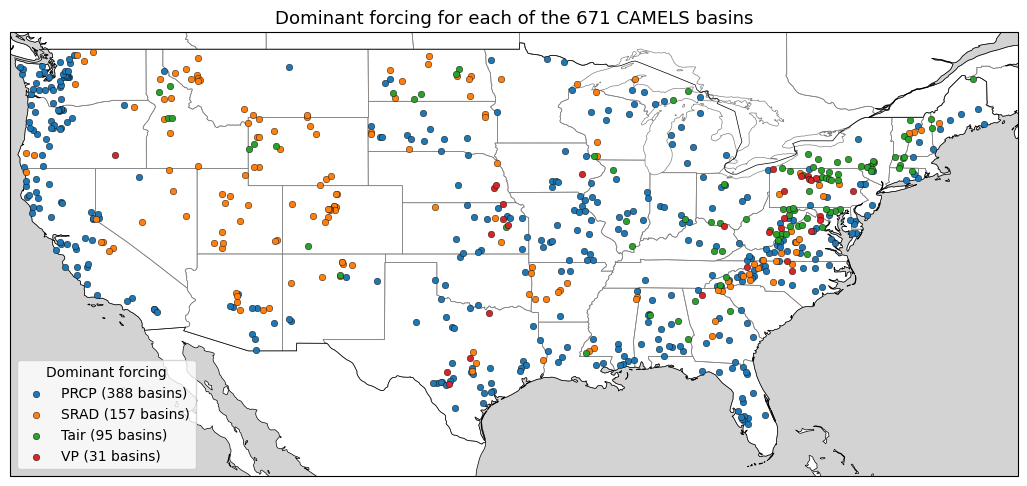

Saved: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Research -CAMELS\Analysis of all 671 basin\outputs\pdf\CONUS_map_dominant_forcing.pdf
Saved: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Research -CAMELS\Analysis of all 671 basin\outputs\pdf\CONUS_map_dominant_forcing.png


In [26]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Pull lat/lon from merged_df
loc_df = merged_df[["gauge_id", "gauge_lat", "gauge_lon"]].copy()
map_df = master_df.merge(loc_df, on="gauge_id", how="left")

# Color for each forcing
forcing_colors = {"PRCP": "#1f77b4", "SRAD": "#ff7f0e", "Tair": "#2ca02c", "VP": "#d62728"}

fig = plt.figure(figsize=(13, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

# Basemap features
ax.add_feature(cfeature.LAND, facecolor="white")
ax.add_feature(cfeature.OCEAN, facecolor="lightgray")
ax.add_feature(cfeature.STATES, edgecolor="gray", linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, edgecolor="black", linewidth=0.5)
ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=0.5)

# Plot basins by dominant forcing
for f in forcings:
    sub = map_df[map_df["dominant_forcing"] == f]
    ax.scatter(sub["gauge_lon"], sub["gauge_lat"],
               s=22, color=forcing_colors[f], edgecolor="black", linewidth=0.3,
               label=f"{f} ({len(sub)} basins)",
               transform=ccrs.PlateCarree(), zorder=5)

ax.legend(loc="lower left", fontsize=10, frameon=True, title="Dominant forcing")
ax.set_title("Dominant forcing for each of the 671 CAMELS basins", fontsize=13)

# Save as PDF and PNG
out_pdf = PDF_DIR / "CONUS_map_dominant_forcing.pdf"
out_png = PDF_DIR / "CONUS_map_dominant_forcing.png"
plt.savefig(out_pdf, bbox_inches="tight", dpi=200)
plt.savefig(out_png, bbox_inches="tight", dpi=200)
plt.show()

print("Saved:", out_pdf)
print("Saved:", out_png)

## Interpretation of the dominant forcing map

The map shows clear geographic patterns in dominant forcing across the United States.

PRCP-dominant basins (blue) are spread throughout the country but concentrate most heavily in the Southeast, the Pacific Northwest coast, and Texas. These are humid or storm-driven regions where rainfall is the main water input. PRCP also dominates in many basins along the Atlantic coast and parts of the central US, which fits the picture of direct rainfall-runoff control.

SRAD-dominant basins (orange) are mostly in the western United States. They cluster across the Rocky Mountains, the Great Basin, the desert Southwest, and parts of the Pacific Northwest. This pattern is consistent with energy-driven hydrology in mountainous and arid basins, where solar radiation governs snowmelt timing and ET. The strong concentration of orange in the West confirms that SRAD dominance is largely a western US phenomenon.

Tair-dominant basins (green) are most visible in the northern tier of the country — the upper Midwest, Northeast, northern Great Lakes, and a band across the northern Plains. They also show up in the Appalachians. This matches the snow-driven story exactly. Cooler northern basins where snow plays a strong role in the water balance let temperature control streamflow timing through melt processes.

VP-dominant basins (red) are few and scattered, but they cluster mainly in the central-eastern US — Ohio, Pennsylvania, parts of the Midwest, and one cluster in central Texas. These tend to be humid, forested basins where humidity-driven ET shapes streamflow.

A few honest observations from this map. The east-west split between PRCP and SRAD is real and very visible — this is the same pattern that showed up as gauge_lon being a top driver in three of four groups. The Tair cluster in the northern Northeast and Great Lakes is the clearest single regional signal in the map, and it lines up perfectly with snow-driven hydrology. The Texas region is unusual because it shows a mix of all four colors in close proximity, which suggests the dominance is weakly separated for some of those basins, and the map should not be over-interpreted there. Overall, the spatial coherence of the four groups supports the attribute-based story from the previous step.

## CONUS map of dominant peak lag per basin

In this step, I plot the same 671 basins on a CONUS map, but this time I color each point by the peak lag of the dominant forcing, in days. Short lags (1–2 days) mean the basin responds quickly to its dominant forcing, which is typical of rainfall-runoff systems. Long lags (10–30 days) mean the response is slow, which is typical of snowmelt-driven or storage-driven basins. Plotting peak lag on a map shows the spatial pattern of response time across the country.

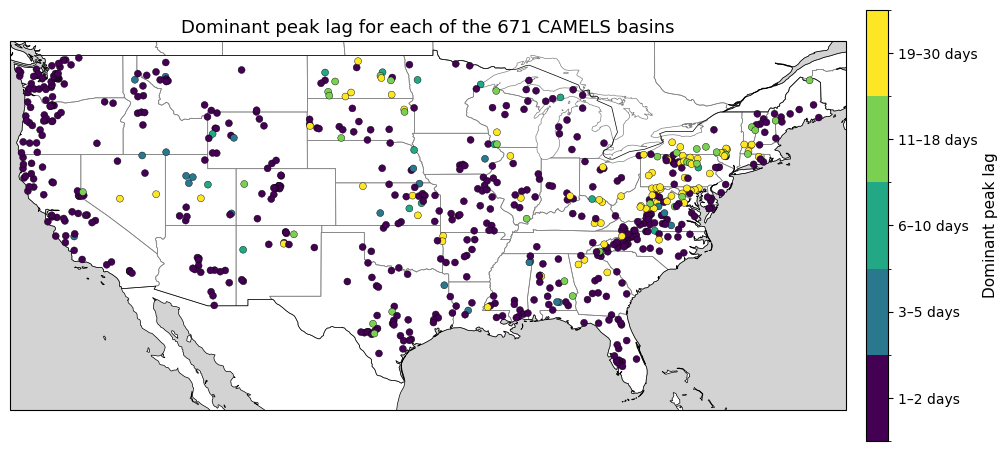

Saved: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Research -CAMELS\Analysis of all 671 basin\outputs\pdf\CONUS_map_dominant_peak_lag.pdf
Saved: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Research -CAMELS\Analysis of all 671 basin\outputs\pdf\CONUS_map_dominant_peak_lag.png

Basins by lag category:
dominant_peak_lag
1–2 days      514
3–5 days       23
6–10 days      15
11–18 days     37
19–30 days     82
Name: count, dtype: int64


In [30]:
from matplotlib.colors import BoundaryNorm, ListedColormap

# Define the 5 lag categories
lag_bins = [0.5, 2.5, 5.5, 10.5, 18.5, 30.5]   # boundaries (so 1-2, 3-5, 6-10, 11-18, 19-30)
lag_labels = ["1–2 days", "3–5 days", "6–10 days", "11–18 days", "19–30 days"]

# Same viridis colors as before, but reversed: dark purple = short lag, yellow = long lag
lag_colors = ["#440154", "#2a788e", "#22a884", "#7ad151", "#fde725"]

cmap = ListedColormap(lag_colors)
norm = BoundaryNorm(lag_bins, ncolors=cmap.N)

fig = plt.figure(figsize=(13, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

# Basemap features
ax.add_feature(cfeature.LAND, facecolor="white")
ax.add_feature(cfeature.OCEAN, facecolor="lightgray")
ax.add_feature(cfeature.STATES, edgecolor="gray", linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, edgecolor="black", linewidth=0.5)
ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=0.5)

# Plot basins with discrete lag colors
sc = ax.scatter(map_df["gauge_lon"], map_df["gauge_lat"],
                c=map_df["dominant_peak_lag"], cmap=cmap, norm=norm,
                s=25, edgecolor="black", linewidth=0.3,
                transform=ccrs.PlateCarree(), zorder=5)

# Discrete colorbar
cbar = plt.colorbar(sc, ax=ax, orientation="vertical", shrink=0.7, pad=0.02,
                    ticks=[1.5, 4, 8, 14.5, 24.5])
cbar.ax.set_yticklabels(lag_labels)
cbar.set_label("Dominant peak lag", fontsize=11)

ax.set_title("Dominant peak lag for each of the 671 CAMELS basins", fontsize=13)

# Save (replace previous files with same names)
out_pdf = PDF_DIR / "CONUS_map_dominant_peak_lag.pdf"
out_png = PDF_DIR / "CONUS_map_dominant_peak_lag.png"
plt.savefig(out_pdf, bbox_inches="tight", dpi=200)
plt.savefig(out_png, bbox_inches="tight", dpi=200)
plt.show()

print("Saved:", out_pdf)
print("Saved:", out_png)
print()

# Show how many basins fall in each lag category
counts = pd.cut(map_df["dominant_peak_lag"], bins=lag_bins, labels=lag_labels).value_counts().sort_index()
print("Basins by lag category:")
print(counts)

## Interpretation of the dominant peak lag map

The lag map shows a clear and somewhat surprising pattern across the 671 basins.

Most basins, 514 out of 671 (about 77%), have a dominant peak lag of just 1–2 days. These short-lag basins (dark purple) cover most of the country, especially the Southeast, Pacific Northwest coast, Texas, and large parts of the Great Plains. The pattern is consistent with rainfall-driven streamflow systems where the dominant forcing produces a quick response within a day or two.

The middle lag range (3–10 days) is sparsely populated, with only 38 basins combined. This means very few basins fall between fast rainfall response and slower snow or storage-driven response. Instead, the data show a roughly bimodal pattern: basins are mostly fast or mostly slow, with little in between.

The longer-lag groups stand out clearly. The 11–18 day basins (37 basins, light green) and the 19–30 day basins (82 basins, yellow) form visible clusters. Many of them appear in the upper Midwest, the Northeast, and the central-eastern US, including Pennsylvania, Ohio, Virginia, and parts of New England. There are also long-lag basins scattered through the Rockies and northern Plains. Some of these long-lag basins fit the snowmelt picture (cool, snowy, forested), but many do not. Long-lag basins in central Pennsylvania, Ohio, and Virginia are too low and too warm for snow to be the main reason. For those basins, the long lag likely reflects vapor pressure or radiation acting through slow ET-storage processes, not snowmelt.

Two honest takeaways from this map. First, the bimodal lag distribution is a real finding, not a plotting artifact. It suggests that the 671 basins separate into a "fast rainfall" regime and a "slow energy or moisture" regime, with very few basins in between. Second, long lag does not automatically mean snowmelt. The yellow cluster in the central-eastern US is a strong reminder that long lags can also come from humidity-driven and storage-driven processes. This matches the small but consistent VP-dominant group identified in the previous step, which had a high mean peak lag and was concentrated in similar regions.

Together with the dominant forcing map, this lag map gives me two complementary pictures: the forcing map shows which forcing wins, and the lag map shows how fast or slow the response is. A basin's full identity is the combination of both, and the per-basin top-10 driver table provides the attribute-based reason behind it.

## CONUS map of dominant peak TE strength per basin

In this step, I plot the same 671 basins on a CONUS map and color each one by the strength of its dominant peak TE. This shows where information flow from forcings to streamflow is strong and where it is weak. Combined with the dominant forcing map and the peak lag map, this gives me the full picture: which forcing dominates each basin, how fast the response is, and how strong the relationship is.

I first check the distribution of dominant peak TE so I can choose sensible color bins.

In [31]:
# Check distribution of dominant peak TE
print("Dominant peak TE distribution across 671 basins:")
print(map_df["dominant_peak_te"].describe().round(4))
print()
print("Quantiles:")
for q in [0.10, 0.25, 0.50, 0.75, 0.90, 0.95]:
    print(f"  {int(q*100):>3d}%: {map_df['dominant_peak_te'].quantile(q):.4f}")

Dominant peak TE distribution across 671 basins:
count    671.0000
mean       0.0061
std        0.0051
min        0.0004
25%        0.0027
50%        0.0043
75%        0.0080
max        0.0341
Name: dominant_peak_te, dtype: float64

Quantiles:
   10%: 0.0018
   25%: 0.0027
   50%: 0.0043
   75%: 0.0080
   90%: 0.0121
   95%: 0.0168


## Plot dominant peak TE strength on CONUS map

In this step, I plot all 671 basins colored by the strength of their dominant peak TE, using five categories that roughly split the basins into very weak, weak, moderate, strong, and very strong groups. The bin boundaries come from the data quantiles. Dark purple marks basins where the strongest forcing-to-Q signal is weak. Yellow marks basins where the dominant signal is very strong.

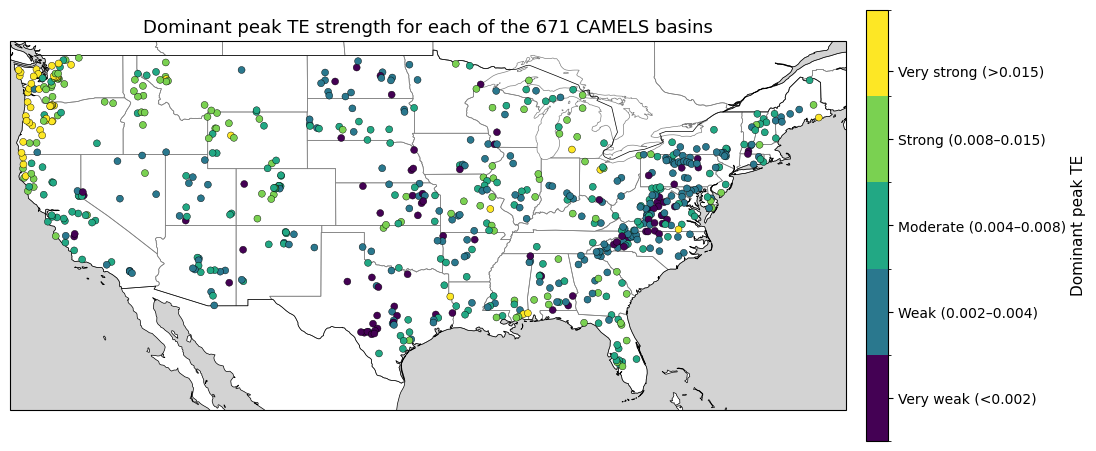

Saved: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Research -CAMELS\Analysis of all 671 basin\outputs\pdf\CONUS_map_dominant_peak_te.pdf
Saved: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Research -CAMELS\Analysis of all 671 basin\outputs\pdf\CONUS_map_dominant_peak_te.png

Basins by TE strength category:
dominant_peak_te
Very weak (<0.002)         84
Weak (0.002–0.004)        228
Moderate (0.004–0.008)    191
Strong (0.008–0.015)      120
Very strong (>0.015)       48
Name: count, dtype: int64


In [32]:
# Define the 5 TE strength categories (boundaries chosen from quantile inspection)
te_bins   = [0, 0.002, 0.004, 0.008, 0.015, 0.05]
te_labels = ["Very weak (<0.002)",
             "Weak (0.002–0.004)",
             "Moderate (0.004–0.008)",
             "Strong (0.008–0.015)",
             "Very strong (>0.015)"]

# Same viridis-style colors, dark purple = weak, yellow = strong
te_colors = ["#440154", "#2a788e", "#22a884", "#7ad151", "#fde725"]

cmap = ListedColormap(te_colors)
norm = BoundaryNorm(te_bins, ncolors=cmap.N)

fig = plt.figure(figsize=(13, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

# Basemap features
ax.add_feature(cfeature.LAND, facecolor="white")
ax.add_feature(cfeature.OCEAN, facecolor="lightgray")
ax.add_feature(cfeature.STATES, edgecolor="gray", linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, edgecolor="black", linewidth=0.5)
ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=0.5)

# Plot basins with discrete TE colors
sc = ax.scatter(map_df["gauge_lon"], map_df["gauge_lat"],
                c=map_df["dominant_peak_te"], cmap=cmap, norm=norm,
                s=25, edgecolor="black", linewidth=0.3,
                transform=ccrs.PlateCarree(), zorder=5)

# Discrete colorbar
cbar = plt.colorbar(sc, ax=ax, orientation="vertical", shrink=0.7, pad=0.02,
                    ticks=[0.001, 0.003, 0.006, 0.0115, 0.025])
cbar.ax.set_yticklabels(te_labels)
cbar.set_label("Dominant peak TE", fontsize=11)

ax.set_title("Dominant peak TE strength for each of the 671 CAMELS basins", fontsize=13)

# Save
out_pdf = PDF_DIR / "CONUS_map_dominant_peak_te.pdf"
out_png = PDF_DIR / "CONUS_map_dominant_peak_te.png"
plt.savefig(out_pdf, bbox_inches="tight", dpi=200)
plt.savefig(out_png, bbox_inches="tight", dpi=200)
plt.show()

print("Saved:", out_pdf)
print("Saved:", out_png)
print()

counts = pd.cut(map_df["dominant_peak_te"], bins=te_bins, labels=te_labels).value_counts().sort_index()
print("Basins by TE strength category:")
print(counts)

## Interpretation of the dominant peak TE strength map

The TE strength map shows where the dominant forcing-to-Q signal is strong and where it is weak across the 671 basins.

The strongest TE values (yellow, very strong, peak TE > 0.015) cluster very clearly along the Pacific Northwest coast, in Washington and Oregon. The strong category (light green, 0.008–0.015) extends into northern California, parts of the Mountain West, and a few basins in the Northeast and Appalachians. These are mostly humid, high-runoff basins where rainfall translates directly and cleanly into streamflow, so the information flow from the dominant forcing to Q is strong.

The very weak TE values (dark purple, < 0.002) are concentrated in Texas, the southern Plains, and parts of the desert Southwest. These are dry, water-limited basins with intermittent or noisy streamflow. In such basins, even when one forcing dominates the others, the absolute TE value remains low because the streamflow signal itself does not carry much organized information from any forcing.

Most of the country sits in the moderate (green, 0.004–0.008) and weak (teal, 0.002–0.004) range. These are the typical CAMELS basins — neither extremely responsive nor extremely noisy.

The split across the 671 basins is roughly: 84 very weak, 228 weak, 191 moderate, 120 strong, and 48 very strong. This shows that strong dominant TE is the exception, not the rule. Most basins have moderate or weaker dominance signals.

A careful note on interpretation. The TE strength map combines two things: how clearly the dominant forcing controls Q, and how clean the Q signal itself is. A basin can be PRCP-dominant but still show weak TE if its streamflow is noisy or intermittent. So weak TE in dry regions does not mean the forcing is unimportant. It means the data does not allow a strong signal to be detected. This is a key reason why the per-basin attribute analysis is needed: it tells us why each basin behaves the way it does, even when the TE value alone is small.

Together, the three CONUS maps now give me the full picture: which forcing dominates (Map 1), how fast the response is (Map 2), and how strong the dominant signal is (Map 3). For any of the 671 basins, I can read all three properties from the maps, then look up the attribute-based explanation in the per-basin driver table.

## CONUS maps of the six most important attributes

In this step, I plot six key CAMELS attributes across all 671 basins on CONUS maps. These are the attributes that appeared most often as top drivers across the four forcing groups: frac_snow, aridity, frac_forest, pet_mean, runoff_ratio, and p_seasonality. Plotting them on the same kind of map as the dominant forcing map lets me visually compare the attribute pattern with the dominance pattern. If a forcing dominates where a particular attribute stands out, the two maps should overlap.

In [36]:
# Rebuild map_df cleanly: master_df + lat/lon + all numeric attributes, no duplicates
map_df = master_df.copy()
# Drop any leftover lat/lon columns from earlier merges
for c in ["gauge_lat", "gauge_lon", "gauge_lat_x", "gauge_lat_y", "gauge_lon_x", "gauge_lon_y"]:
    if c in map_df.columns:
        map_df = map_df.drop(columns=c)

# Bring in lat/lon and all numeric attributes from merged_df in one merge
extra = merged_df[["gauge_id", "gauge_lat", "gauge_lon"] + numeric_attr_cols].copy()
# Drop duplicates within numeric_attr_cols list (gauge_lat/lon are also in numeric_attr_cols)
extra = extra.loc[:, ~extra.columns.duplicated()]

map_df = map_df.merge(extra, on="gauge_id", how="left")

print("map_df shape:", map_df.shape)
print("Number of basins:", map_df["gauge_id"].nunique())
print("gauge_lat present?:", "gauge_lat" in map_df.columns)
print("frac_snow present?:", "frac_snow" in map_df.columns)

map_df shape: (671, 112)
Number of basins: 671
gauge_lat present?: True
frac_snow present?: True


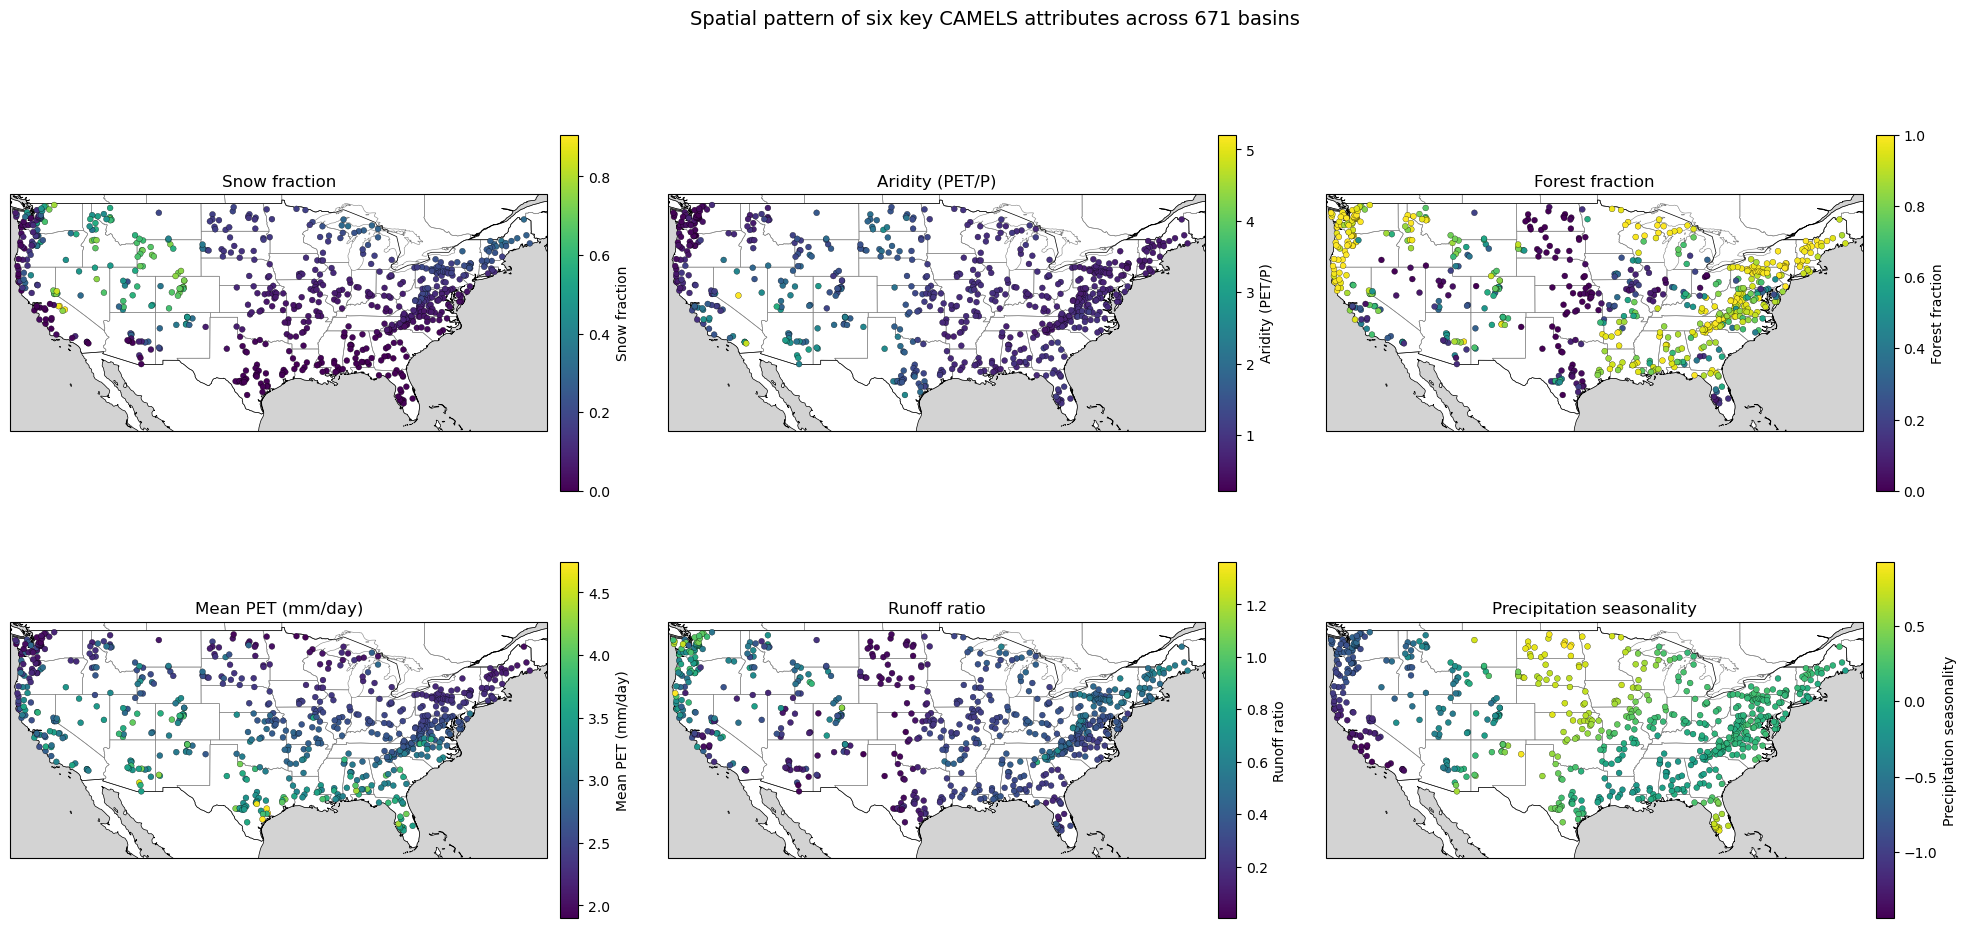

Saved: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Research -CAMELS\Analysis of all 671 basin\outputs\pdf\CONUS_maps_six_key_attributes.pdf
Saved: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Research -CAMELS\Analysis of all 671 basin\outputs\pdf\CONUS_maps_six_key_attributes.png


In [37]:
# The six key attributes and titles for each subplot
attr_to_plot = [
    ("frac_snow",     "Snow fraction"),
    ("aridity",       "Aridity (PET/P)"),
    ("frac_forest",   "Forest fraction"),
    ("pet_mean",      "Mean PET (mm/day)"),
    ("runoff_ratio",  "Runoff ratio"),
    ("p_seasonality", "Precipitation seasonality"),
]

fig, axes = plt.subplots(2, 3, figsize=(20, 10),
                         subplot_kw={"projection": ccrs.PlateCarree()})
axes = axes.flatten()

for ax, (attr, title) in zip(axes, attr_to_plot):
    ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="white")
    ax.add_feature(cfeature.OCEAN, facecolor="lightgray")
    ax.add_feature(cfeature.STATES, edgecolor="gray", linewidth=0.4)
    ax.add_feature(cfeature.COASTLINE, edgecolor="black", linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=0.5)

    sub = map_df.dropna(subset=[attr])
    sc = ax.scatter(sub["gauge_lon"], sub["gauge_lat"],
                    c=sub[attr], cmap="viridis",
                    s=18, edgecolor="black", linewidth=0.2,
                    transform=ccrs.PlateCarree(), zorder=5)

    cbar = plt.colorbar(sc, ax=ax, orientation="vertical", shrink=0.7, pad=0.02)
    cbar.set_label(title, fontsize=10)
    ax.set_title(title, fontsize=12)

plt.suptitle("Spatial pattern of six key CAMELS attributes across 671 basins", fontsize=14, y=1.00)
plt.tight_layout()

# Save
out_pdf = PDF_DIR / "CONUS_maps_six_key_attributes.pdf"
out_png = PDF_DIR / "CONUS_maps_six_key_attributes.png"
plt.savefig(out_pdf, bbox_inches="tight", dpi=200)
plt.savefig(out_png, bbox_inches="tight", dpi=200)
plt.show()

print("Saved:", out_pdf)
print("Saved:", out_png)

## Interpretation of the six attribute maps

These six maps together explain the dominant forcing map from the previous step. Each attribute pattern lines up with where one or more of the four forcings dominates.

Snow fraction is high in the northern Rockies, Sierra Nevada, Cascades, upper Midwest, and Northeast, and is essentially zero through the South and Southwest. This pattern matches where Tair-dominant basins are concentrated. The visual overlap is direct confirmation that snow is the main reason temperature controls streamflow in those basins.

Aridity is high in the desert Southwest, southern Plains, and parts of California, and low in the Pacific Northwest and the eastern US. This dry-west, wet-east split is the foundation of the east-west PRCP and SRAD pattern seen in the dominant forcing map. Wetter basins favor PRCP dominance, drier basins shift toward energy-driven SRAD dominance.

Forest fraction is highest in the Pacific Northwest, northern Rockies, and the entire eastern US, and lowest in the Plains and Southwest. Forest cover overlaps clearly with the Tair-dominant and VP-dominant clusters, supporting the role of forests in slowing streamflow and shaping ET-driven processes.

Mean PET is highest in Texas, Florida, and the southern Plains, and lowest in the high mountains and northern basins. This pattern explains why Tair dominance is rare in warm, high-PET regions and concentrated in cool, low-PET northern basins.

Runoff ratio is very high along the Pacific Northwest coast and low in the Plains and Southwest. This map is the visual reason for the dominant peak TE strength map. Pacific Northwest basins have the strongest TE because nearly all rainfall becomes streamflow there. Plains and Southwest basins have weak TE because most water is lost to evaporation before it can reach the stream.

Precipitation seasonality is strongly negative in California (rainfall concentrated in winter) and positive in the northern Plains (rainfall concentrated in summer), and is near zero across most of the East. The strong seasonality in the West is one reason SRAD dominance shows up in those regions: when rainfall is concentrated in one season, the energy cycle becomes the dominant control on streamflow timing.

Taken together, these six attribute maps show that the four forcing groups are not random. Each group sits in a specific climatic and landscape setting:

- PRCP-dominant basins in humid, low-aridity, forested eastern regions.
- SRAD-dominant basins in dry, mountainous, seasonal western regions.
- Tair-dominant basins in cool, snowy, forested northern regions.
- VP-dominant basins in humid, forested, low-PET eastern and central regions.

The visual alignment between the attribute maps and the dominance map strengthens the per-basin driver analysis. The patterns we identified through driver scores match what these maps show directly.